# **Laptop Price Prediction Using ML**

## ***Importing Required Libraries***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from google.colab import drive, files
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import loguniform


## ***Mount Google Drive and Extract Dataset***

In [ ]:
drive.mount('/content/drive')
zip_file_path = '/content/drive/MyDrive/project-1-laptop-price-prediction.zip'

!mkdir -p /content/laptop_dataset

!unzip -o '/content/drive/MyDrive/project-1-laptop-price-prediction.zip' -d /content/laptop_dataset

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  /content/drive/MyDrive/project-1-laptop-price-prediction.zip
  inflating: /content/laptop_dataset/test_data.csv  
  inflating: /content/laptop_dataset/train_data.csv  


## ***Load Dataset***

In [ ]:
train_df = pd.read_csv("/content/laptop_dataset/train_data.csv")
test_df  = pd.read_csv("/content/laptop_dataset/test_data.csv")

In [ ]:
test_ids = test_df["id"]

## ***EDA Before Preprocessing***

### Dataset Overview

In [ ]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (881, 16)
Test shape: (394, 15)


In [ ]:
train_df.head()

,id,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [ ]:
train_df.describe()

,id,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro)
count,881.00000,881.000000,881.000000,881.000000,881.000000,881.000000
mean,441.00000,15.085017,2.281839,8.522134,2.049714,1110.183235
std,254.46709,1.396360,0.527334,4.921176,0.657077,711.526332
min,1.00000,10.100000,0.900000,2.000000,0.690000,191.900000
25%,221.00000,14.000000,1.800000,4.000000,1.580000,589.000000
50%,441.00000,15.600000,2.500000,8.000000,2.040000,945.000000
75%,661.00000,15.600000,2.700000,8.000000,2.300000,1426.660000
max,881.00000,18.400000,3.600000,32.000000,4.700000,6099.000000


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   881 non-null    int64  
 1   Company              881 non-null    object 
 2   Product              881 non-null    object 
 3   TypeName             881 non-null    object 
 4   Inches               881 non-null    float64
 5   ScreenResolution     881 non-null    object 
 6   CPU_Company          881 non-null    object 
 7   CPU_Type             881 non-null    object 
 8   CPU_Frequency (GHz)  881 non-null    float64
 9   RAM (GB)             881 non-null    int64  
 10  Memory               881 non-null    object 
 11  GPU_Company          881 non-null    object 
 12  GPU_Type             881 non-null    object 
 13  OpSys                881 non-null    object 
 14  Weight (kg)          881 non-null    float64
 15  Price (Euro)         881 non-null    flo

In [ ]:
train_df.isna().sum() #byshuf el cloumns el fiha missing values

,0
id,0
Company,0
Product,0
TypeName,0
Inches,0
ScreenResolution,0
CPU_Company,0
CPU_Type,0
CPU_Frequency (GHz),0
RAM (GB),0


In [ ]:
test_df.isna().sum()

,0
id,0
Company,0
Product,0
TypeName,0
Inches,0
ScreenResolution,0
CPU_Company,0
CPU_Type,0
CPU_Frequency (GHz),0
RAM (GB),0


In [ ]:
train_df.duplicated().sum()

np.int64(0)

In [ ]:
print(train_df.columns)

Index(['id', 'Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution',
       'CPU_Company', 'CPU_Type', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Memory',
       'GPU_Company', 'GPU_Type', 'OpSys', 'Weight (kg)', 'Price (Euro)'],
      dtype='object')


In [ ]:
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = train_df.select_dtypes(include=['object']).columns

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

for col in categorical_cols:
    print(f"\n{col} -> {train_df[col].nunique()} unique values")
    print(train_df[col].value_counts().head(10))

Numeric columns:
Index(['id', 'Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)',
       'Price (Euro)'],
      dtype='object')

Categorical columns:
Index(['Company', 'Product', 'TypeName', 'ScreenResolution', 'CPU_Company',
       'CPU_Type', 'Memory', 'GPU_Company', 'GPU_Type', 'OpSys'],
      dtype='object')

Company -> 19 unique values
Company
Lenovo      207
Dell        205
HP          157
Asus        116
Acer         76
Toshiba      31
MSI          30
Apple        17
Mediacom      7
Samsung       7
Name: count, dtype: int64

Product -> 451 unique values
Product
Inspiron 3567         19
Inspiron 5570         18
XPS 13                17
250 G6                17
Legion Y520-15IKBN    15
Satellite Pro         13
Alienware 17          11
Vostro 3568           10
MacBook Pro           10
Latitude 5580         10
Name: count, dtype: int64

TypeName -> 6 unique values
TypeName
Notebook              503
Gaming                135
Ultrabook             134
2 in 1 Convertible     72

In [ ]:
train_df["OpSys"].value_counts()

,count
OpSys,
Windows 10,735
No OS,50
Linux,45
Chrome OS,17
macOS,13
Windows 7,8
Windows 10 S,8
Mac OS X,4
Android,1


In [ ]:
train_df["CPU_Type"].value_counts().head(20)

,count
CPU_Type,
Core i5 7200U,134
Core i7 7700HQ,117
Core i7 7500U,91
Core i5 8250U,71
Core i7 8550U,71
Core i3 6006U,63
Core i5 7300HQ,28
Celeron Dual Core N3350,27
Core i3 7100U,24


In [ ]:
train_df[["CPU_Frequency (GHz)", "Price (Euro)"]].corr()

,CPU_Frequency (GHz),Price (Euro)
CPU_Frequency (GHz),1.000000,0.451539
Price (Euro),0.451539,1.000000


In [ ]:
train_df.groupby("Product").size().sort_values(ascending=False).head(10)

,0
Product,
Inspiron 3567,19
Inspiron 5570,18
XPS 13,17
250 G6,17
Legion Y520-15IKBN,15
Satellite Pro,13
Alienware 17,11
MacBook Pro,10
Vostro 3568,10


In [ ]:
train_df["Product"].str.split().str[0].nunique()

180

###  EDA Visualizations

#### Price Distribution (Histogram)

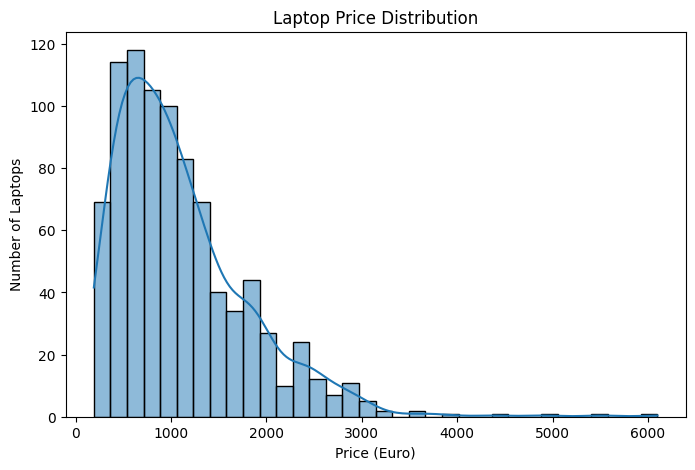

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(train_df['Price (Euro)'], kde=True)

plt.title("Laptop Price Distribution")
plt.xlabel("Price (Euro)")
plt.ylabel("Number of Laptops")

plt.show()

**The price distribution is right-skewed, with most laptops priced between 500–1500 €, while a small number of laptops reach prices up to about 6000 €.**

#### Price Boxplot

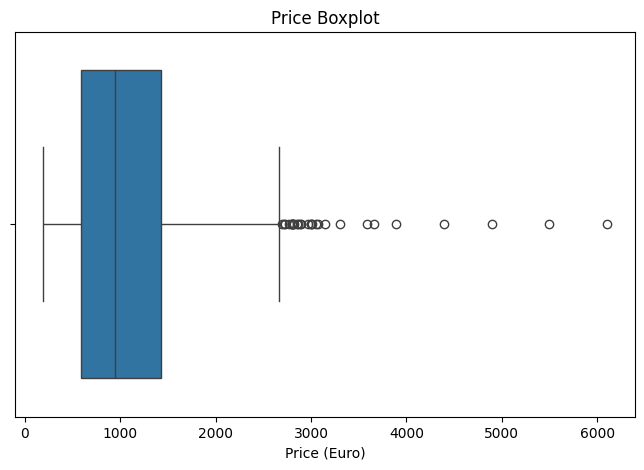

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=train_df['Price (Euro)'])
plt.title("Price Boxplot")
plt.show()

**The boxplot shows that most laptop prices fall between approximately 700 € and 1500 €, with a median price around 1100 €. A few high-price outliers are present, reaching up to around 6000 €.**

#### Feature Correlation Heatmap

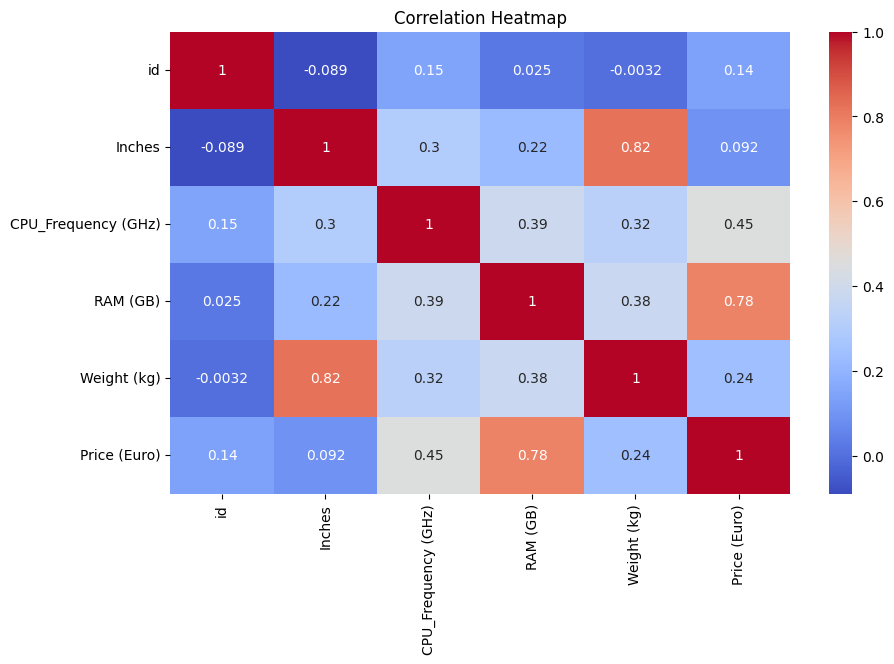

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**The correlation heatmap shows that RAM has the strongest positive correlation with price (0.78), while CPU frequency has a moderate correlation (0.45). Screen size and weight show weaker relationships with price.**

#### Relationship Between RAM and Laptop Price (Scatter Plot)

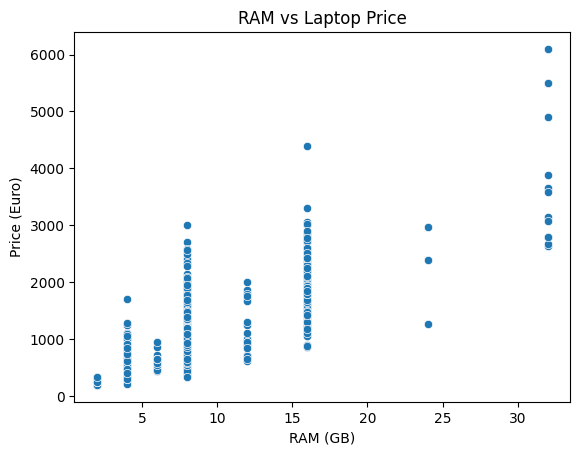

In [ ]:
sns.scatterplot(x=train_df['RAM (GB)'], y=train_df['Price (Euro)'])
plt.title("RAM vs Laptop Price")
plt.show()

**The scatter plot shows a positive relationship between RAM and laptop price, where laptops with higher RAM tend to be more expensive.**

#### Relationship Between CPU Frequency and Laptop Price (Scatter Plot)

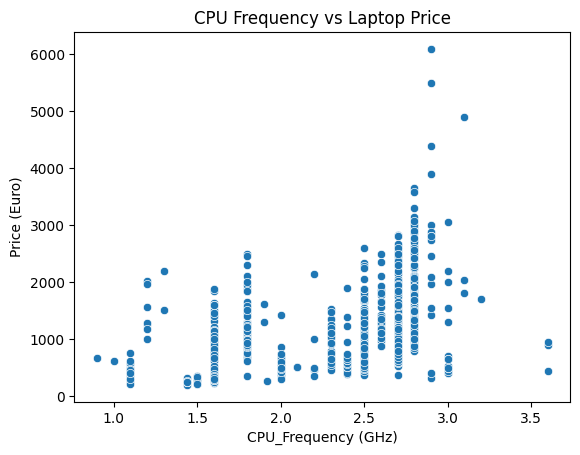

In [ ]:
sns.scatterplot(x=train_df['CPU_Frequency (GHz)'], y=train_df['Price (Euro)'])
plt.title("CPU Frequency vs Laptop Price")
plt.show()

**The scatter plot shows a moderate positive relationship between CPU frequency and laptop price, indicating that laptops with higher CPU frequencies generally tend to have higher prices.**

## ***preprocessing***

In [ ]:
# Handle extreme price outliers
price_cap = train_df["Price (Euro)"].quantile(0.995)

train_df["Price (Euro)"] = np.where(
    train_df["Price (Euro)"] > price_cap,
    price_cap,
    train_df["Price (Euro)"]
)


X = train_df.drop("Price (Euro)", axis=1)
y = train_df["Price (Euro)"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train.copy()
X_val = X_val.copy()
test_df = test_df.copy()

In [ ]:
# GPU feature engineering

# get GPU series
def gpu_series(x):

    if pd.isna(x):
        return "Unknown"

    x = str(x).lower()

    if "rtx" in x:
        return "RTX"
    elif "gtx" in x:
        return "GTX"
    elif "mx" in x:
        return "MX"
    elif "radeon" in x:
        return "Radeon"
    elif "hd" in x:
        return "HD"
    else:
        return "Other"


# apply to train, validation and test
for df in [X_train, X_val, test_df]:
    df["GPU_Series"] = df["GPU_Type"].apply(gpu_series)

    # remove the original column
    df.drop("GPU_Type", axis=1, inplace=True)


In [ ]:
# screen resolution features
for df in [X_train, X_val, test_df]:

    df["Touchscreen"] = df["ScreenResolution"].astype(str).str.contains("Touchscreen", na=False).astype(int)

    df["IPS"] = df["ScreenResolution"].astype(str).str.contains("IPS", na=False).astype(int)

    resolution = df["ScreenResolution"].astype(str).str.extract(r"(\d+)x(\d+)")
    df["X_res"] = pd.to_numeric(resolution[0], errors="coerce")
    df["Y_res"] = pd.to_numeric(resolution[1], errors="coerce")

    df["PPI"] = ((df["X_res"]**2 + df["Y_res"]**2) ** 0.5) / df["Inches"]

    df.drop(["ScreenResolution", "X_res", "Y_res"], axis=1, inplace=True)

In [ ]:
# memory features
for df in [X_train, X_val, test_df]:

    # standardize memory text
    df["Memory"] = df["Memory"].astype(str).str.replace(".0", "", regex=False)
    df["Memory"] = df["Memory"].str.replace("TB", "000GB", regex=False)

    # create storage columns
    df["SSD"] = 0
    df["HDD"] = 0
    df["Flash_Storage"] = 0
    df["Hybrid"] = 0

    for i in df.index:

        item = str(df.loc[i, "Memory"]).lower()
        parts = item.split("+")

        for part in parts:
            part = part.strip()

            # get storage size
            size = "".join(ch for ch in part if ch.isdigit())
            size = int(size) if size else 0

            if "ssd" in part:
                df.loc[i, "SSD"] += size
            elif "hdd" in part:
                df.loc[i, "HDD"] += size
            elif "flash" in part:
                df.loc[i, "Flash_Storage"] += size
            elif "hybrid" in part:
                df.loc[i, "Hybrid"] += size

    # total storage
    df["Total_Storage"] = df["SSD"] + df["HDD"] + df["Flash_Storage"] + df["Hybrid"]

# remove original memory column
for df in [X_train, X_val, test_df]:
    df.drop("Memory", axis=1, inplace=True)

In [ ]:
def simplify_os(x):
    if pd.isna(x):
        return "Unknown"
    x = str(x).lower()

    if 'windows' in x:
        return 'Windows'
    elif 'mac' in x:
        return 'Mac'
    elif 'linux' in x:
        return 'Linux'
    elif 'chrome' in x:
        return 'ChromeOS'
    elif 'no os' in x:
        return 'No OS'
    else:
        return 'Other'


def simplify_cpu(cpu):
    if pd.isna(cpu):
        return "Unknown"
    cpu = str(cpu).lower()

    if 'i3' in cpu:
        return 'Core i3'
    elif 'i5' in cpu:
        return 'Core i5'
    elif 'i7' in cpu:
        return 'Core i7'
    elif 'i9' in cpu:
        return 'Core i9'
    elif 'ryzen' in cpu:
        return 'Ryzen'
    elif 'celeron' in cpu:
        return 'Celeron'
    elif 'pentium' in cpu:
        return 'Pentium'
    elif 'atom' in cpu:
        return 'Atom'
    elif 'a9' in cpu or 'a6' in cpu or 'a12' in cpu:
        return 'AMD A-Series'
    else:
        return 'Other'


# Apply feature extraction
for df in [X_train, X_val, test_df]:
    df["OS_Group"] = df["OpSys"].apply(simplify_os)
    df["CPU_Family"] = df["CPU_Type"].apply(simplify_cpu)

    df.drop(columns=["OpSys", "CPU_Type"], errors="ignore", inplace=True)

In [ ]:
# Final engineered features


for df in [X_train, X_val, test_df]:

    df["Storage_Type_Count"] = (
    (df["SSD"] > 0).astype(int) +
    (df["HDD"] > 0).astype(int) +
    (df["Flash_Storage"] > 0).astype(int) +
    (df["Hybrid"] > 0).astype(int)
)

    df["RAM_CPU"] = df["RAM (GB)"] * df["CPU_Frequency (GHz)"]

    df["Screen_Quality"] = df["PPI"] * (1 + df["IPS"]) * (1 + df["Touchscreen"])

    df["Storage_per_RAM"] = df["Total_Storage"] / (df["RAM (GB)"] + 1)

    df["CPU_per_PPI"] = df["CPU_Frequency (GHz)"] / (df["PPI"] + 1)

    df["RAM_per_Inch"] = df["RAM (GB)"] / (df["Inches"] + 1)

    df["GPU_Is_Dedicated"] = df["GPU_Company"].isin(["Nvidia", "AMD"]).astype(int)

    df["Hybrid_Flag"] = (df["Hybrid"] > 0).astype(int)

In [ ]:
# Product family feature
for df in [X_train, X_val, test_df]:
    df["Product_Brand_Family"] = df["Product"].astype(str).str.split().str[0]

In [ ]:
#remove columns (kol el examples nafs el haga)
constant_cols = [col for col in X_train.columns if X_train[col].nunique() <= 1]

X_train = X_train.drop(columns=constant_cols)
X_val = X_val.drop(columns=constant_cols)
test_df = test_df.drop(columns=constant_cols)

print("Removed constant columns:", len(constant_cols))

Removed constant columns: 0


In [ ]:
#features used
original_cols_to_drop = [
    "RAM (GB)",
    "CPU_Frequency (GHz)",
    "Inches"
]

for df in [X_train, X_val, test_df]:
    df.drop(columns=original_cols_to_drop, inplace=True, errors="ignore")

In [ ]:
#high cardinality w amalt bih feature
for df in [X_train, X_val, test_df]:
    df.drop(columns=["Product"], inplace=True, errors="ignore")

In [ ]:
# One-hot encoding

X_train = pd.get_dummies(X_train, drop_first=False)
X_val = pd.get_dummies(X_val, drop_first=False)
test_df = pd.get_dummies(test_df, drop_first=False)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
test_df = test_df.reindex(columns=X_train.columns, fill_value=0)

print("Shapes after encoding:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("test_df:", test_df.shape)

print("\nTrain vs Val same columns:", list(X_train.columns) == list(X_val.columns))
print("Train vs Test same columns:", list(X_train.columns) == list(test_df.columns))

Shapes after encoding:
X_train: (704, 215)
X_val  : (177, 215)
test_df: (394, 215)

Train vs Val same columns: True
Train vs Test same columns: True


In [ ]:
# Feature scaling


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
test_scaled = scaler.transform(test_df)

print(np.mean(X_train_scaled[:, 0]), np.std(X_train_scaled[:, 0]))

-7.569702440626067e-17 0.9999999999999999


In [ ]:
np.mean(X_train_scaled[:,0]), np.std(X_train_scaled[:,0])

(np.float64(-7.569702440626067e-17), np.float64(0.9999999999999999))

In [ ]:
print(X_train.columns)

Index(['id', 'Weight (kg)', 'Touchscreen', 'IPS', 'PPI', 'SSD', 'HDD',
       'Flash_Storage', 'Hybrid', 'Total_Storage',
       ...
       'Product_Brand_Family_X550VX-XX015D',
       'Product_Brand_Family_X555BP-XX180T',
       'Product_Brand_Family_X555QG-DM242T',
       'Product_Brand_Family_X751NV-TY001', 'Product_Brand_Family_XPS',
       'Product_Brand_Family_Yoga', 'Product_Brand_Family_ZBook',
       'Product_Brand_Family_Zbook', 'Product_Brand_Family_ZenBook',
       'Product_Brand_Family_Zenbook'],
      dtype='object', length=215)


## ***Modeling***

In [ ]:
# K-FOLD
kf = KFold(n_splits=5, shuffle=True, random_state=42)

### Linear Regression

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name} Performance on Validation Set:")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R²  :", r2)

In [ ]:
# Gradient Descent Linear Regression

gd_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("gd", SGDRegressor(
        loss="squared_error",
        penalty=None,
        learning_rate="adaptive",
        eta0=0.001,
        max_iter=20000,
        tol=1e-4,
        random_state=42
    ))
])

gd_pipeline.fit(X_train, y_train)


y_pred_gd = gd_pipeline.predict(X_val)


evaluate_model(y_val, y_pred_gd, "Gradient Descent Linear Regression")


# K-Fold Cross Validation
gd_rmse_scores = cross_val_score(
    gd_pipeline,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

gd_rmse_scores = -gd_rmse_scores

print("Gradient Descent K-Fold RMSE:", gd_rmse_scores)
print("Average K-Fold RMSE:", gd_rmse_scores.mean())
print("Std RMSE:", gd_rmse_scores.std())

Gradient Descent Linear Regression Performance on Validation Set:
RMSE: 254.25892168133768
MAE : 173.61256728804582
R²  : 0.873924468991881


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Gradient Descent K-Fold RMSE: [275.26186894 276.41162858 244.72321486 242.28968069 311.25198662]
Average K-Fold RMSE: 269.98767593687546
Std RMSE: 25.208330169602117


### Polynomial Regression

In [ ]:
# POLYNOMIAL REGRESSION

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold

# Polynomial Feature Selection


poly_features = [
    'RAM (GB)',
    'CPU_Frequency (GHz)',
    'PPI',
    'Weight (kg)',
    'Total_Storage',
    'RAM_CPU',
    'Storage_per_RAM',
    'Screen_Quality'
]

poly_features = [c for c in poly_features if c in X_train.columns]

print("Polynomial Features Used:")
print(poly_features)

# Base Scaling


base_scaler = StandardScaler()

X_train_base = base_scaler.fit_transform(X_train[poly_features].astype(float))
X_val_base = base_scaler.transform(X_val[poly_features].astype(float))

y_train_np = y_train.values.astype(float)
y_val_np = y_val.values.astype(float)

# Manual Polynomial Expansion

poly_degree = 2

poly_transformer = PolynomialFeatures(
    degree=poly_degree,
    include_bias=False
)

X_train_poly_raw = poly_transformer.fit_transform(X_train_base)
X_val_poly_raw = poly_transformer.transform(X_val_base)

print("Polynomial shape:", X_train_poly_raw.shape)


# Scale Polynomial Features


poly_scaler = StandardScaler()

X_train_poly = poly_scaler.fit_transform(X_train_poly_raw)
X_val_poly = poly_scaler.transform(X_val_poly_raw)


# Prediction Function

poly_model = SGDRegressor(
    loss="squared_error",
    penalty="l2",
    alpha=0.0001,
    learning_rate="constant",
    eta0=0.001,
    max_iter=6000,
    tol=1e-6,
    random_state=42
)

# Cost Function with L2 Regularization


poly_model.fit(X_train_poly, y_train_np)

y_train_pred = poly_model.predict(X_train_poly)
y_val_pred = poly_model.predict(X_val_poly)

train_cost = mean_squared_error(y_train_np, y_train_pred) / 2
val_cost = mean_squared_error(y_val_np, y_val_pred) / 2

print("Train Cost:", train_cost)
print("Val Cost:", val_cost)



y_pred_poly = poly_model.predict(X_val_poly)

evaluate_model(y_val, y_pred_poly, "Polynomial Regression (SGD + L2)")



# K-Fold Evaluation


kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = []

X_poly_full = X_train[poly_features].copy()
y_poly_full = y_train.copy()

for train_idx, val_idx in kf.split(X_poly_full):
    X_tr = X_poly_full.iloc[train_idx]
    X_va = X_poly_full.iloc[val_idx]

    y_tr = y_poly_full.iloc[train_idx]
    y_va = y_poly_full.iloc[val_idx]

    # base scaling
    fold_base_scaler = StandardScaler()
    X_tr_base = fold_base_scaler.fit_transform(X_tr.astype(float))
    X_va_base = fold_base_scaler.transform(X_va.astype(float))

    # polynomial expansion
    fold_poly_transformer = PolynomialFeatures(
        degree=poly_degree,
        include_bias=False
    )
    X_tr_poly_raw = fold_poly_transformer.fit_transform(X_tr_base)
    X_va_poly_raw = fold_poly_transformer.transform(X_va_base)

    # polynomial scaling
    fold_poly_scaler = StandardScaler()
    X_tr_poly = fold_poly_scaler.fit_transform(X_tr_poly_raw)
    X_va_poly = fold_poly_scaler.transform(X_va_poly_raw)

    # model
    fold_model = SGDRegressor(
        loss="squared_error",
        penalty="l2",
        alpha=0.0001,
        learning_rate="constant",
        eta0=0.001,
        max_iter=6000,
        tol=1e-6,
        random_state=42
    )

    fold_model.fit(X_tr_poly, y_tr.values.astype(float))
    fold_preds = fold_model.predict(X_va_poly)

    fold_r2 = r2_score(y_va, fold_preds)
    r2_scores.append(fold_r2)

print("Polynomial KFold R2:", r2_scores)
print("Average:", np.mean(r2_scores))

Polynomial Features Used:
['PPI', 'Weight (kg)', 'Total_Storage', 'RAM_CPU', 'Storage_per_RAM', 'Screen_Quality']
Polynomial shape: (704, 27)
Train Cost: 53242.18767099266
Val Cost: 60053.64090886477
Polynomial Regression (SGD + L2) Performance on Validation Set:
RMSE: 346.5649748859938
MAE : 250.47384792706112
R²  : 0.7657671822663277
Polynomial KFold R2: [0.7448730328209543, 0.7116476636820696, 0.7415144304797582, 0.7508624614908777, 0.7188831245610781]
Average: 0.7335561426069475


### Ridge Regression

In [ ]:
# Ridge Regression using Gradient Descent

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

ridge_gd_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge_gd", SGDRegressor(
        loss="squared_error",
        penalty="l2",
        alpha=0.001,
        learning_rate="constant",
        eta0=0.0001,
        max_iter=20000,
        tol=1e-6,
        random_state=42
    ))
])


ridge_gd_pipeline.fit(X_train, y_train)


y_pred_ridge_gd = ridge_gd_pipeline.predict(X_val)


evaluate_model(y_val, y_pred_ridge_gd, "Ridge Regression (Gradient Descent)")
print("Ridge GD R2:", r2_score(y_val, y_pred_ridge_gd))

# Cross Validation


ridge_gd_rmse_scores = cross_val_score(
    ridge_gd_pipeline,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

ridge_gd_rmse_scores = -ridge_gd_rmse_scores

print("Ridge GD K-Fold RMSE:", ridge_gd_rmse_scores)
print("Average K-Fold RMSE:", ridge_gd_rmse_scores.mean())
print("Std RMSE:", ridge_gd_rmse_scores.std())

Ridge Regression (Gradient Descent) Performance on Validation Set:
RMSE: 253.2163948711582
MAE : 171.636387344068
R²  : 0.8749562334417369
Ridge GD R2: 0.8749562334417369
Ridge GD K-Fold RMSE: [272.41056013 274.81004911 243.45556121 237.15556072 307.59852624]
Average K-Fold RMSE: 267.08605148203924
Std RMSE: 25.232936772116272


In [ ]:
#Tuning


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

alphas = np.logspace(-4, 3, 50)

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

best_alpha = None
best_rmse = float("inf")

for a in alphas:

    ridge_pipeline.set_params(ridge__alpha=a)

    scores = cross_val_score(
        ridge_pipeline,
        X_train,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=kf,
        n_jobs=-1
    )

    rmse_scores = -scores
    avg_rmse = rmse_scores.mean()

    print(f"Alpha: {a:.6f} | RMSE: {avg_rmse:.4f} | Std: {rmse_scores.std():.4f}")

    if avg_rmse < best_rmse:
        best_rmse = avg_rmse
        best_alpha = a


print("\nBest alpha:", best_alpha)
print("Best CV RMSE:", best_rmse)


best_ridge_alpha = best_alpha

Alpha: 0.000100 | RMSE: 273.0684 | Std: 25.5834
Alpha: 0.000139 | RMSE: 273.0683 | Std: 25.5834
Alpha: 0.000193 | RMSE: 273.0682 | Std: 25.5834
Alpha: 0.000268 | RMSE: 273.0681 | Std: 25.5834
Alpha: 0.000373 | RMSE: 273.0679 | Std: 25.5834
Alpha: 0.000518 | RMSE: 273.0676 | Std: 25.5833
Alpha: 0.000720 | RMSE: 273.0672 | Std: 25.5833
Alpha: 0.001000 | RMSE: 273.0667 | Std: 25.5832
Alpha: 0.001389 | RMSE: 273.0659 | Std: 25.5831
Alpha: 0.001931 | RMSE: 273.0649 | Std: 25.5830
Alpha: 0.002683 | RMSE: 273.0634 | Std: 25.5828
Alpha: 0.003728 | RMSE: 273.0614 | Std: 25.5825
Alpha: 0.005179 | RMSE: 273.0586 | Std: 25.5822
Alpha: 0.007197 | RMSE: 273.0547 | Std: 25.5817
Alpha: 0.010000 | RMSE: 273.0493 | Std: 25.5810
Alpha: 0.013895 | RMSE: 273.0419 | Std: 25.5800
Alpha: 0.019307 | RMSE: 273.0315 | Std: 25.5787
Alpha: 0.026827 | RMSE: 273.0172 | Std: 25.5769
Alpha: 0.037276 | RMSE: 272.9973 | Std: 25.5743
Alpha: 0.051795 | RMSE: 272.9699 | Std: 25.5708
Alpha: 0.071969 | RMSE: 272.9321 | Std: 

In [ ]:
# Train Best Ridge Model


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

best_ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=best_ridge_alpha))
])


best_ridge_pipeline.fit(X_train, y_train)


y_pred_best_ridge = best_ridge_pipeline.predict(X_val)

# Evaluate on validation set
evaluate_model(y_val, y_pred_best_ridge, "Best Ridge Regression")


# Cross Validation Check


best_ridge_rmse_scores = cross_val_score(
    best_ridge_pipeline,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

best_ridge_rmse_scores = -best_ridge_rmse_scores

print("Best Ridge K-Fold RMSE:", best_ridge_rmse_scores)
print("Best Ridge Average RMSE:", best_ridge_rmse_scores.mean())
print("Best Ridge Std RMSE:", best_ridge_rmse_scores.std())

Best Ridge Regression Performance on Validation Set:
RMSE: 252.6352848936548
MAE : 168.91044264654874
R²  : 0.8755295043894398
Best Ridge K-Fold RMSE: [245.60611651 280.39906401 247.99370169 230.77771619 287.71696506]
Best Ridge Average RMSE: 258.49871268936346
Best Ridge Std RMSE: 21.809904166752812


### lasso

In [ ]:

# Lasso Regression using Gradient Descent

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

lasso_gd_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso_gd", SGDRegressor(
        loss="squared_error",
        penalty="l1",
        alpha=0.001,
        learning_rate="constant",
        eta0=0.0001,
        max_iter=50000,
        tol=1e-6,
        random_state=42
    ))
])


lasso_gd_pipeline.fit(X_train, y_train)
y_pred_lasso_gd = lasso_gd_pipeline.predict(X_val)

# Evaluate on validation set (log scale)
evaluate_model(y_val, y_pred_lasso_gd, "Lasso Regression (Gradient Descent)")

Lasso Regression (Gradient Descent) Performance on Validation Set:
RMSE: 253.27542726119796
MAE : 171.7151896202403
R²  : 0.8748979236877892


In [ ]:
lasso_gd_rmse_scores = cross_val_score(
    lasso_gd_pipeline,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

lasso_gd_rmse_scores = -lasso_gd_rmse_scores

print("Lasso GD K-Fold RMSE:", lasso_gd_rmse_scores)
print("Average K-Fold RMSE:", lasso_gd_rmse_scores.mean())
print("Std RMSE:", lasso_gd_rmse_scores.std())

Lasso GD K-Fold RMSE: [272.66442357 274.80417828 242.97666383 237.29239208 307.78937283]
Average K-Fold RMSE: 267.1054061173527
Std RMSE: 25.36285049372077


In [ ]:
# Save as best model
best_lasso_gd_model = lasso_gd_pipeline

y_pred_best_lasso_gd = y_pred_lasso_gd

### Regression trees

In [ ]:
# Decision Tree Hyperparameter Tuning


from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
import numpy as np

# Parameter search space
depths = [6, 8, 10, 12, 15]
min_splits = [2, 5, 10]
min_leaves = [1, 2, 4]

best_depth = None
best_split = None
best_leaf = None
best_rmse = float("inf")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for d in depths:
    for split in min_splits:
        for leaf in min_leaves:

            tree = DecisionTreeRegressor(
                criterion="squared_error",
                max_depth=d,
                min_samples_split=split,
                min_samples_leaf=leaf,
                random_state=42
            )

            scores = cross_val_score(
                tree,
                X_train, #features
                y_train, #target
                scoring="neg_root_mean_squared_error",
                cv=kf
            )

            rmse = -scores.mean()

            print(f"Depth={d}, Split={split}, Leaf={leaf}, RMSE={rmse:.2f}")

            if rmse < best_rmse:
                best_rmse = rmse
                best_depth = d
                best_split = split
                best_leaf = leaf

print("\nBest Parameters Found:")
print("Best Depth:", best_depth)
print("Best Split:", best_split)
print("Best Leaf:", best_leaf)
print("Best CV RMSE:", best_rmse)


tree_model = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=best_depth,
    min_samples_split=best_split,
    min_samples_leaf=best_leaf,
    random_state=42
)

tree_model.fit(X_train, y_train)

# Validation evaluation
y_pred_tree = tree_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred_tree))
print("\nValidation RMSE:", rmse)

Depth=6, Split=2, Leaf=1, RMSE=341.24
Depth=6, Split=2, Leaf=2, RMSE=342.12
Depth=6, Split=2, Leaf=4, RMSE=330.25
Depth=6, Split=5, Leaf=1, RMSE=346.21
Depth=6, Split=5, Leaf=2, RMSE=337.86
Depth=6, Split=5, Leaf=4, RMSE=330.25
Depth=6, Split=10, Leaf=1, RMSE=339.60
Depth=6, Split=10, Leaf=2, RMSE=334.12
Depth=6, Split=10, Leaf=4, RMSE=327.53
Depth=8, Split=2, Leaf=1, RMSE=349.01
Depth=8, Split=2, Leaf=2, RMSE=342.76
Depth=8, Split=2, Leaf=4, RMSE=327.10
Depth=8, Split=5, Leaf=1, RMSE=342.79
Depth=8, Split=5, Leaf=2, RMSE=344.12
Depth=8, Split=5, Leaf=4, RMSE=327.10
Depth=8, Split=10, Leaf=1, RMSE=329.24
Depth=8, Split=10, Leaf=2, RMSE=334.37
Depth=8, Split=10, Leaf=4, RMSE=322.97
Depth=10, Split=2, Leaf=1, RMSE=356.30
Depth=10, Split=2, Leaf=2, RMSE=361.28
Depth=10, Split=2, Leaf=4, RMSE=328.92
Depth=10, Split=5, Leaf=1, RMSE=343.63
Depth=10, Split=5, Leaf=2, RMSE=345.09
Depth=10, Split=5, Leaf=4, RMSE=328.92
Depth=10, Split=10, Leaf=1, RMSE=332.99
Depth=10, Split=10, Leaf=2, RMSE=336

In [ ]:
tree_model = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=best_depth,
    min_samples_split=best_split,
    min_samples_leaf=best_leaf,
    random_state=42
)

In [ ]:
# Train
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_val)

evaluate_model(y_val, y_pred_tree, "Regression Tree")

# K-Fold RMSE
tree_rmse_scores = cross_val_score(
    tree_model,
    X_train,
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=kf
)

print("Regression Tree K-Fold RMSE:", -tree_rmse_scores)
print("Regression Tree Average RMSE:", -tree_rmse_scores.mean())

Regression Tree Performance on Validation Set:
RMSE: 335.976110206199
MAE : 235.40106463200954
R²  : 0.7798619070846234
Regression Tree K-Fold RMSE: [252.63951013 353.03187661 351.09779841 290.50874896 357.35197766]
Regression Tree Average RMSE: 320.9259823546535


## ***Model Comparison***

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_val_original = y_val

linear_pred_original = y_pred_gd
poly_pred_original = y_pred_poly
tree_pred_original = y_pred_tree
ridge_pred_original = y_pred_best_ridge
lasso_pred_original = y_pred_lasso_gd

#final comparison table on ORIGINAL price scale
final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Regression Tree",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "RMSE (Euro)": [
        np.sqrt(mean_squared_error(y_val_original, linear_pred_original)),
        np.sqrt(mean_squared_error(y_val_original, poly_pred_original)),
        np.sqrt(mean_squared_error(y_val_original, tree_pred_original)),
        np.sqrt(mean_squared_error(y_val_original, ridge_pred_original)),
        np.sqrt(mean_squared_error(y_val_original, lasso_pred_original))
    ],
    "MAE (Euro)": [
        mean_absolute_error(y_val_original, linear_pred_original),
        mean_absolute_error(y_val_original, poly_pred_original),
        mean_absolute_error(y_val_original, tree_pred_original),
        mean_absolute_error(y_val_original, ridge_pred_original),
        mean_absolute_error(y_val_original, lasso_pred_original)
    ],
    "R2 Score (Original Price)": [
        r2_score(y_val_original, linear_pred_original),
        r2_score(y_val_original, poly_pred_original),
        r2_score(y_val_original, tree_pred_original),
        r2_score(y_val_original, ridge_pred_original),
        r2_score(y_val_original, lasso_pred_original)
    ]
})

final_results = final_results.sort_values(
    by="R2 Score (Original Price)", ascending=False
).reset_index(drop=True)

display(
    final_results.style
    .format({
        "RMSE (Euro)": "{:.2f}",
        "MAE (Euro)": "{:.2f}",
        "R2 Score (Original Price)": "{:.4f}"
    })
    .highlight_max(subset=["R2 Score (Original Price)"], color="lightgreen")
    .highlight_min(subset=["RMSE (Euro)", "MAE (Euro)"], color="lightgreen")
)

best_model = final_results.iloc[0]["Model"]
best_r2 = final_results.iloc[0]["R2 Score (Original Price)"]

print(f"\nBest Model on Original Price Scale: {best_model} (R² = {best_r2:.4f})")

,Model,RMSE (Euro),MAE (Euro),R2 Score (Original Price)
0,Ridge Regression,252.64,168.91,0.8755
1,Lasso Regression,253.28,171.72,0.8749
2,Linear Regression,254.26,173.61,0.8739
3,Regression Tree,335.98,235.40,0.7799
4,Polynomial Regression,346.56,250.47,0.7658



Best Model on Original Price Scale: Ridge Regression (R² = 0.8755)


## ***Hyperparameter Tuning (Grid Search & Random Search)***

In [ ]:
# Hyperparameter Tuning: Ridge Grid Search


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid = {
    "ridge__alpha": np.logspace(-4, 3, 50)
}

grid_search_ridge = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

grid_search_ridge.fit(X_train, y_train)


best_ridge_alpha = grid_search_ridge.best_params_["ridge__alpha"]

print("Best alpha from Ridge GridSearch:", best_ridge_alpha)
print("Best CV RMSE from Ridge GridSearch:", -grid_search_ridge.best_score_)

Best alpha from Ridge GridSearch: 138.9495494373136
Best CV RMSE from Ridge GridSearch: 258.49871268936346


In [ ]:
# Hyperparameter Tuning: Ridge Random Search


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_dist = {
    "ridge__alpha": loguniform(1e-4, 1e3)
}

random_search_ridge = RandomizedSearchCV(
    estimator=ridge_pipeline,
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    random_state=42,
    n_jobs=-1
)

random_search_ridge.fit(X_train, y_train)


best_ridge_alpha_random = random_search_ridge.best_params_["ridge__alpha"]

print("Best alpha from Ridge RandomSearch:", best_ridge_alpha_random)
print("Best CV RMSE from Ridge RandomSearch:", -random_search_ridge.best_score_)

Best alpha from Ridge RandomSearch: 115.67327199145953
Best CV RMSE from Ridge RandomSearch: 258.4478424468602


## ***Final Model Evaluation***

In [ ]:
"""## ***Retune Ridge on Original Price Scale***"""

from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Combine
X_all = pd.concat([X_train, X_val], axis=0)


y_all = train_df.loc[X_all.index, "Price (Euro)"]


test_df = test_df[X_all.columns]

#ORIGINAL price scale
alphas = np.logspace(-4, 4, 100)

final_kf = KFold(n_splits=5, shuffle=True, random_state=42)

alpha_results = []

for a in alphas:

    ridge_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=a))
    ])

    cv_scores = cross_val_score(
        ridge_pipeline,
        X_all,
        y_all,
        scoring="neg_root_mean_squared_error",
        cv=final_kf
    )

    rmse_mean = -cv_scores.mean()
    rmse_std = cv_scores.std()

    alpha_results.append({
        "alpha": a,
        "mean_rmse": rmse_mean,
        "std_rmse": rmse_std
    })

alpha_results_df = pd.DataFrame(alpha_results).sort_values("mean_rmse").reset_index(drop=True)

best_alpha = alpha_results_df.loc[0, "alpha"]

print("Best Ridge alpha on ORIGINAL price scale:", best_alpha)
print("Best CV RMSE:", alpha_results_df.loc[0, "mean_rmse"])
print("Top 10 alpha values:")
display(alpha_results_df.head(10))


"""## ***Final Model Evaluation***"""

#  Cross Validation
final_cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=best_alpha))
])

final_cv_scores = cross_val_score(
    final_cv_pipeline,
    X_all,
    y_all,
    scoring="neg_root_mean_squared_error",
    cv=final_kf
)

rmse_scores = -final_cv_scores

print("Final 5-Fold RMSE:", rmse_scores)
print("Final Average RMSE:", rmse_scores.mean())
print("Final Std:", rmse_scores.std())

# Train FINAL Ridge model
final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=best_alpha))
])

final_pipeline.fit(X_all, y_all)


ridge_model = final_pipeline.named_steps["ridge"]

coef_df = pd.DataFrame({
    "Feature": X_all.columns,
    "Coefficient": ridge_model.coef_
})

coef_df["AbsCoef"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("AbsCoef", ascending=False)

print("\nTop 20 Most Important Features:")
display(coef_df.head(20))


final_predictions = final_pipeline.predict(test_df)

train_min = train_df["Price (Euro)"].min()
train_max = train_df["Price (Euro)"].max()
final_predictions = np.clip(final_predictions, train_min, train_max)

submission = pd.DataFrame({
    "id": test_ids,
    "Price": final_predictions
})

print(submission.head())
print("Submission shape:", submission.shape)
print("Null values in submission:")
print(submission.isnull().sum())
print("Duplicate ids:", submission["id"].duplicated().sum())
print("Any negative predictions?", (submission["Price"] < 0).any())
print("Prediction range:", final_predictions.min(), "-", final_predictions.max())

submission.to_csv("submission_ridge_final.csv", index=False)
files.download("submission_ridge_final.csv")

Best Ridge alpha on ORIGINAL price scale: 25.950242113997373
Best CV RMSE: 251.8584531743091
Top 10 alpha values:


,alpha,mean_rmse,std_rmse
0,25.950242,251.858453,26.475787
1,31.257158,251.868480,26.307001
2,21.544347,251.875020,26.646193
3,37.649358,251.905947,26.140880
4,17.886495,251.917533,26.816652
5,45.348785,251.972548,25.977866
6,14.849683,251.985255,26.985135
7,54.622772,252.071877,25.817661
8,12.328467,252.077319,27.149214
9,10.235310,252.192821,27.306167


Final 5-Fold RMSE: [262.13848864 242.84754703 230.39956276 225.52763081 298.37903664]
Final Average RMSE: 251.8584531743091
Final Std: 26.475786784756927

Top 20 Most Important Features:


,Feature,Coefficient,AbsCoef
11,RAM_CPU,156.337612,156.337612
5,SSD,110.868278,110.868278
98,Product_Brand_Family_Alienware,80.118293,80.118293
140,Product_Brand_Family_Inspiron,-73.577523,73.577523
1,Weight (kg),72.510227,72.510227
185,Product_Brand_Family_Thinkpad,67.117649,67.117649
105,Product_Brand_Family_EliteBook,66.341511,66.341511
184,Product_Brand_Family_ThinkPad,64.755406,64.755406
36,TypeName_2 in 1 Convertible,58.672620,58.672620
163,Product_Brand_Family_Precision,57.115553,57.115553


    id        Price
0  882   674.345025
1  883   341.380213
2  884   899.333241
3  885   359.183959
4  886  1515.513160
Submission shape: (394, 2)
Null values in submission:
id       0
Price    0
dtype: int64
Duplicate ids: 0
Any negative predictions? False
Prediction range: 191.9 - 3797.760000000005


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ***Test Data Prediction***

### Comparing Predicted Prices with Training Price Statistics

In [ ]:
### Comparing Predicted Prices with Training Price Statistics

train_prices = train_df["Price (Euro)"]
predicted_prices = pd.Series(final_predictions)

print("Training Price Statistics:")
print(train_prices.describe())

print("\nPredicted Test Price Statistics:")
print(predicted_prices.describe())

print("\nComparison:")

print("Train Mean Price:", train_prices.mean())
print("Predicted Mean Price:", predicted_prices.mean())

print("Train Min Price:", train_prices.min())
print("Predicted Min Price:", predicted_prices.min())

print("Train Max Price:", train_prices.max())
print("Predicted Max Price:", predicted_prices.max())

Training Price Statistics:
count     881.000000
mean     1103.614336
std       678.075087
min       191.900000
25%       589.000000
50%       945.000000
75%      1426.660000
max      3797.760000
Name: Price (Euro), dtype: float64

Predicted Test Price Statistics:
count     394.000000
mean     1237.783383
std       600.827467
min       191.900000
25%       779.007364
50%      1174.055961
75%      1656.427167
max      3797.760000
dtype: float64

Comparison:
Train Mean Price: 1103.6143359818388
Predicted Mean Price: 1237.7833827153588
Train Min Price: 191.9
Predicted Min Price: 191.9
Train Max Price: 3797.760000000005
Predicted Max Price: 3797.760000000005


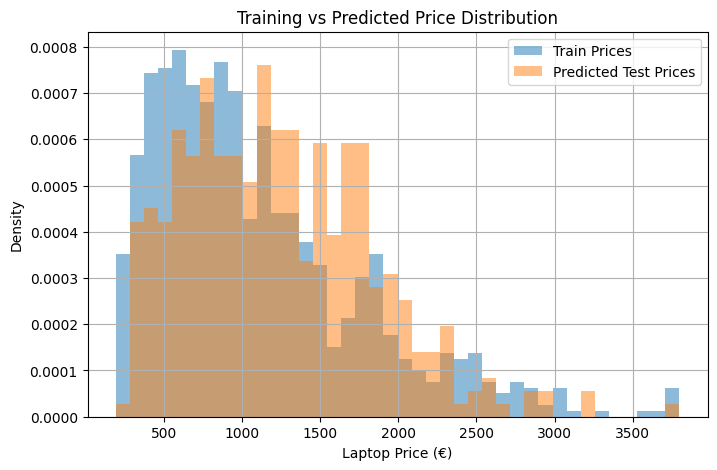

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(train_prices, bins=40, density=True, alpha=0.5, label="Train Prices")
plt.hist(final_predictions, bins=40, density=True, alpha=0.5, label="Predicted Test Prices")

plt.xlabel("Laptop Price (€)")
plt.ylabel("Density")
plt.title("Training vs Predicted Price Distribution")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
submission.head()

,id,Price
0,882,674.345025
1,883,341.380213
2,884,899.333241
3,885,359.183959
4,886,1515.513160


In [ ]:
print("Rows:", submission.shape[0])

print("\nNull values per column:")
print(submission.isnull().sum())

print("\nDuplicate IDs:", submission["id"].duplicated().sum())

Rows: 394

Null values per column:
id       0
Price    0
dtype: int64

Duplicate IDs: 0


mse graph

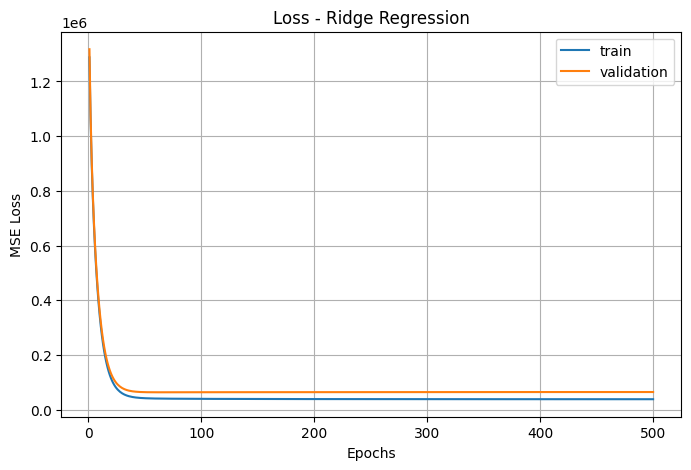

Final Training MSE: 38062.5376399715
Final Validation MSE: 64367.825358911636


In [ ]:

# Requirement 5: Learning Curve for Ridge Regression

from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# trained iteratively
ridge_learning_model = SGDRegressor(
    loss="squared_error",
    penalty="l2",
    alpha=0.01,
    learning_rate="constant",
    eta0=0.0001,
    max_iter=1,
    tol=None,
    warm_start=True,
    random_state=42
)

n_epochs = 500
train_losses = []
val_losses = []

y_train_np = np.array(y_train)
y_val_np = np.array(y_val)

for epoch in range(n_epochs):
    ridge_learning_model.partial_fit(X_train_scaled, y_train_np)

    y_train_pred = ridge_learning_model.predict(X_train_scaled)
    y_val_pred = ridge_learning_model.predict(X_val_scaled)

    train_mse = mean_squared_error(y_train_np, y_train_pred)
    val_mse = mean_squared_error(y_val_np, y_val_pred)

    train_losses.append(train_mse)
    val_losses.append(val_mse)

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label="train")
plt.plot(range(1, n_epochs + 1), val_losses, label="validation")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Loss - Ridge Regression")
plt.legend()
plt.grid(True)
plt.show()

print("Final Training MSE:", train_losses[-1])
print("Final Validation MSE:", val_losses[-1])

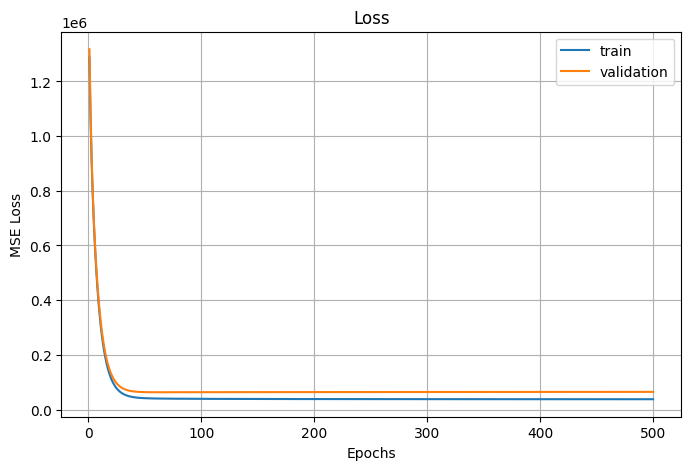

Final Training MSE: 37938.50877535383
Final Validation MSE: 64773.971377674


In [ ]:

# Gradient Descent Linear Regression Learning Curve


from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

gd_learning_model = SGDRegressor(
    loss="squared_error",
    penalty=None,
    learning_rate="constant",
    eta0=0.0001,      # small learning rate for stability
    max_iter=1,
    tol=None,
    warm_start=True,
    random_state=42
)

n_epochs = 500
train_losses = []
val_losses = []

# Convert targets
y_train_np = np.array(y_train)
y_val_np = np.array(y_val)

# Train epoch by epoch
for epoch in range(n_epochs):
    gd_learning_model.partial_fit(X_train_scaled, y_train_np)


    y_train_pred = gd_learning_model.predict(X_train_scaled)
    y_val_pred = gd_learning_model.predict(X_val_scaled)

    # MSE loss
    train_mse = mean_squared_error(y_train_np, y_train_pred)
    val_mse = mean_squared_error(y_val_np, y_val_pred)

    train_losses.append(train_mse)
    val_losses.append(val_mse)


plt.figure(figsize=(8, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label="train")
plt.plot(range(1, n_epochs + 1), val_losses, label="validation")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)
plt.show()


print("Final Training MSE:", train_losses[-1])
print("Final Validation MSE:", val_losses[-1])

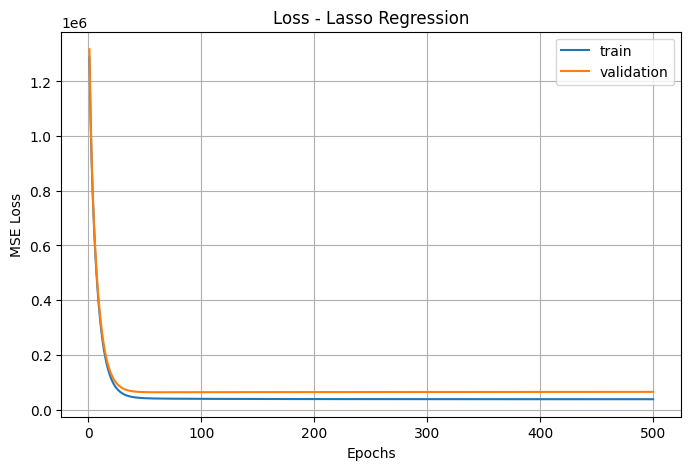

Final Training MSE: 37938.69388936825
Final Validation MSE: 64767.836693301084


In [ ]:
# Gradient Descent Lasso Regression Learning Curve


from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

lasso_learning_model = SGDRegressor(
    loss="squared_error",
    penalty="l1",
    alpha=0.001,
    learning_rate="constant",
    eta0=0.0001,
    max_iter=1,
    tol=None,
    warm_start=True,
    random_state=42
)

n_epochs = 500
train_losses_lasso = []
val_losses_lasso = []

y_train_np = np.array(y_train)
y_val_np = np.array(y_val)

for epoch in range(n_epochs):
    lasso_learning_model.partial_fit(X_train_scaled, y_train_np)

    y_train_pred = lasso_learning_model.predict(X_train_scaled)
    y_val_pred = lasso_learning_model.predict(X_val_scaled)

    train_mse = mean_squared_error(y_train_np, y_train_pred)
    val_mse = mean_squared_error(y_val_np, y_val_pred)

    train_losses_lasso.append(train_mse)
    val_losses_lasso.append(val_mse)

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_epochs + 1), train_losses_lasso, label="train")
plt.plot(range(1, n_epochs + 1), val_losses_lasso, label="validation")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Loss - Lasso Regression")
plt.legend()
plt.grid(True)
plt.show()

print("Final Training MSE:", train_losses_lasso[-1])
print("Final Validation MSE:", val_losses_lasso[-1])